In [1]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('/content/housing.csv',header = None,sep=r'\s+',names = column_names)

In [3]:
data = pd.DataFrame(df)

In [4]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
data['PRICE'] = data['MEDV']
data.drop('MEDV',axis = 1,inplace = True)

In [6]:
data.shape

(506, 14)

In [7]:
data.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')

In [8]:
data.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,int64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,int64
TAX,float64


In [9]:
data.nunique()

,0
CRIM,504
ZN,26
INDUS,76
CHAS,2
NOX,81
RM,446
AGE,356
DIS,412
RAD,9
TAX,66


In [10]:
data.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


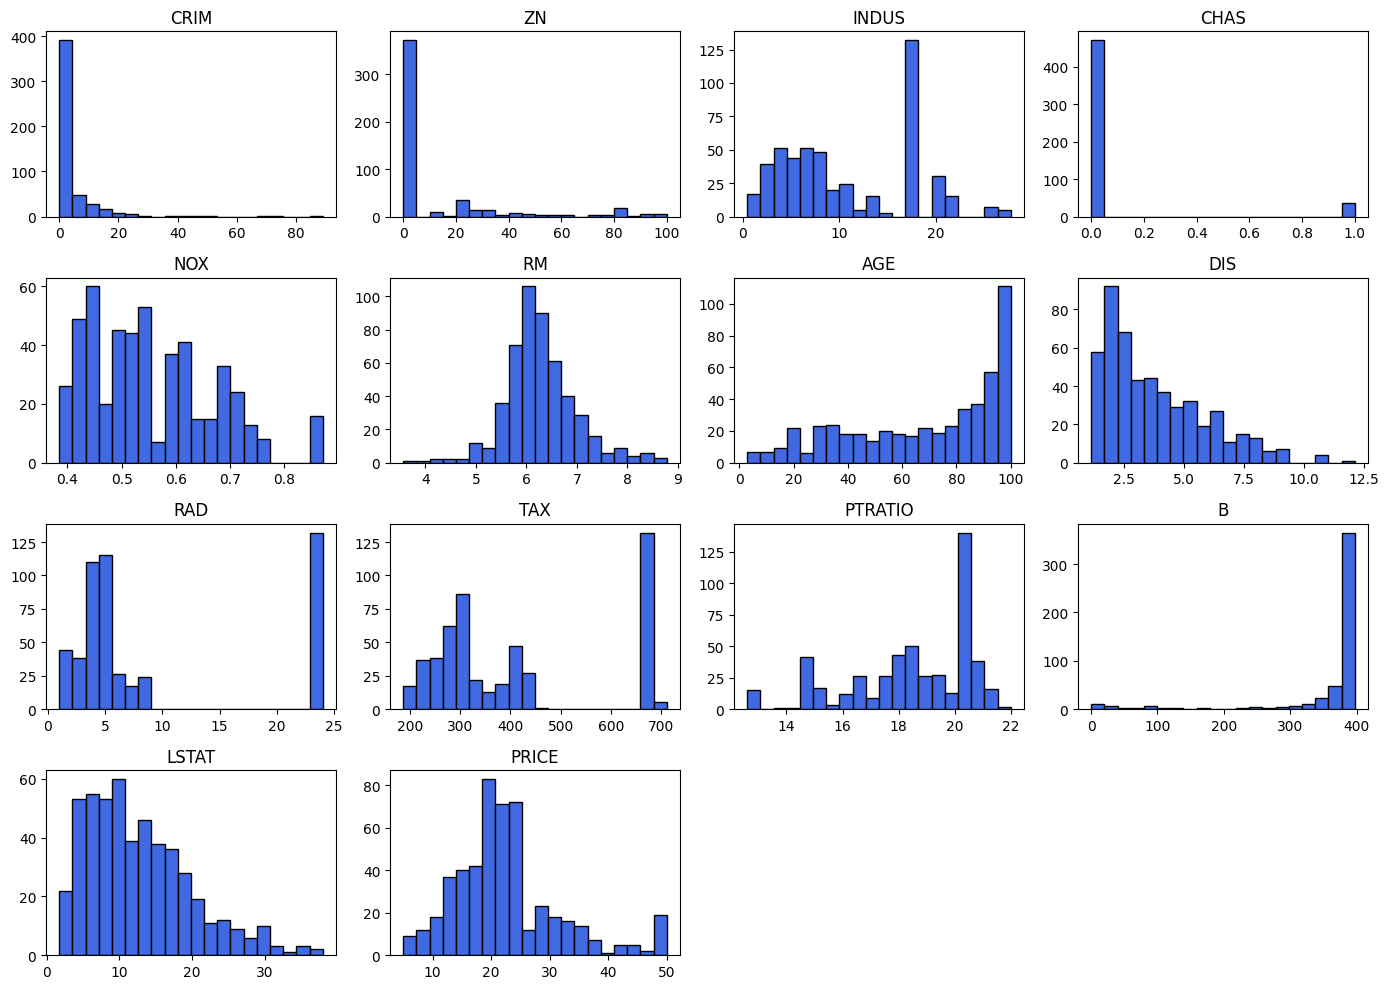

In [12]:
data.hist(bins=20, figsize=(14, 10), grid=False, color='royalblue', edgecolor='black')

# Prevent overlapping labels
plt.tight_layout()
plt.show()


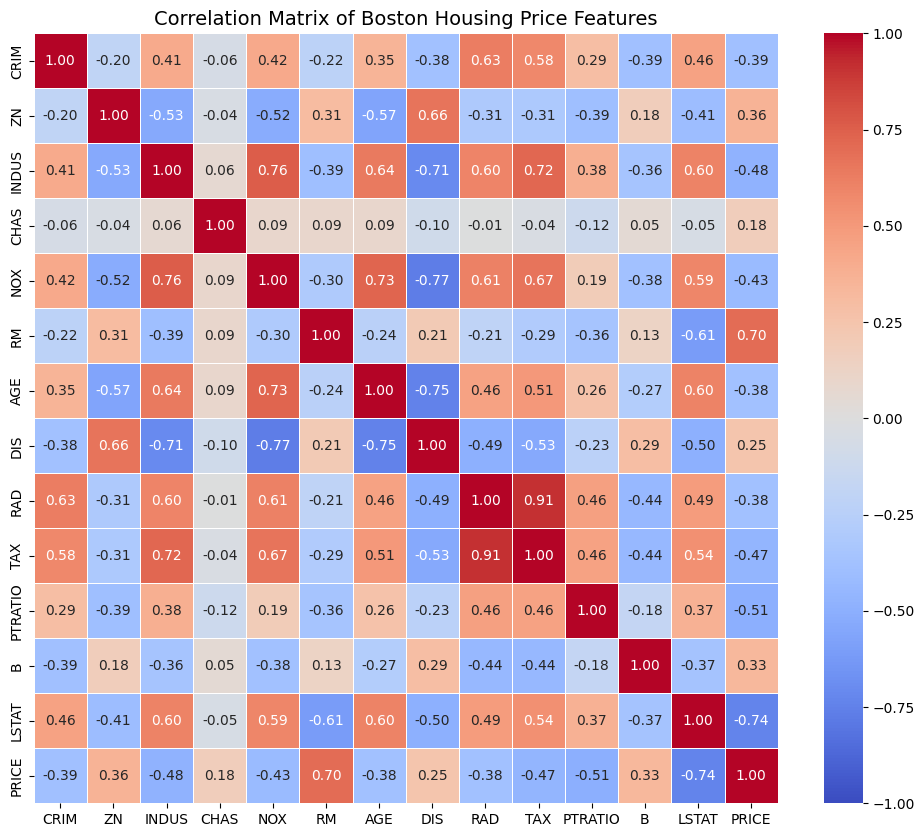

In [13]:
plt.figure(figsize=(12, 10))

#correlation matrix
corr_matrix = data.corr()

# heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Boston Housing Price Features', fontsize=14)
plt.show()


I use scatter plots now because correlation matrix captures only linear relationship between the features.

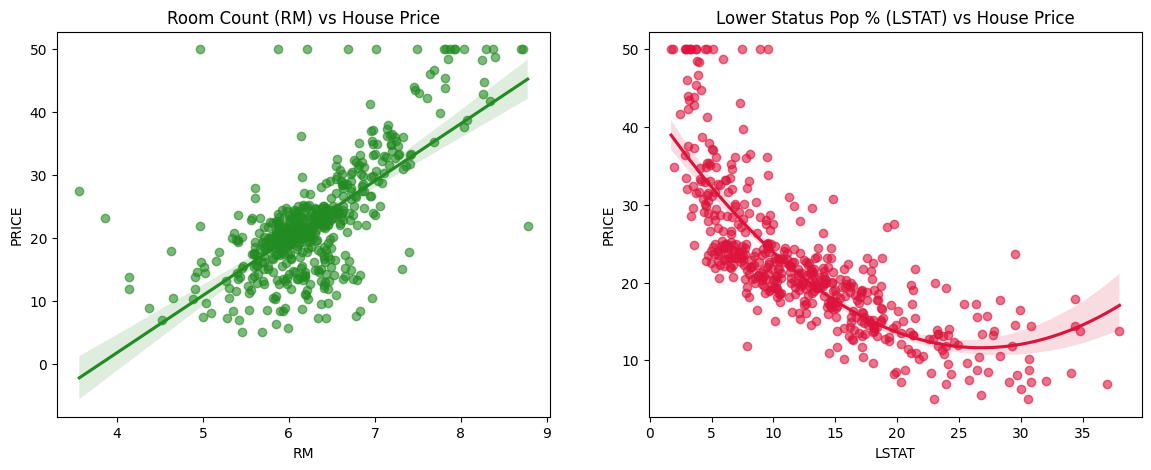

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rooms v/s price relationship
sns.regplot(data=data, x='RM', y='PRICE', ax=axes[0], color='forestgreen', scatter_kws={'alpha':0.6})
axes[0].set_title('Room Count (RM) vs House Price')

# Non-linear Relationship between LSTAT and Price
sns.regplot(data=data, x='LSTAT', y='PRICE', ax=axes[1], color='crimson', scatter_kws={'alpha':0.6}, order=2)
axes[1].set_title('Lower Status Pop % (LSTAT) vs House Price')

plt.show()

Now, I will vizualise the data using boxplot to detect outliers on features like crime(CRIM) and ZN(zoned land)

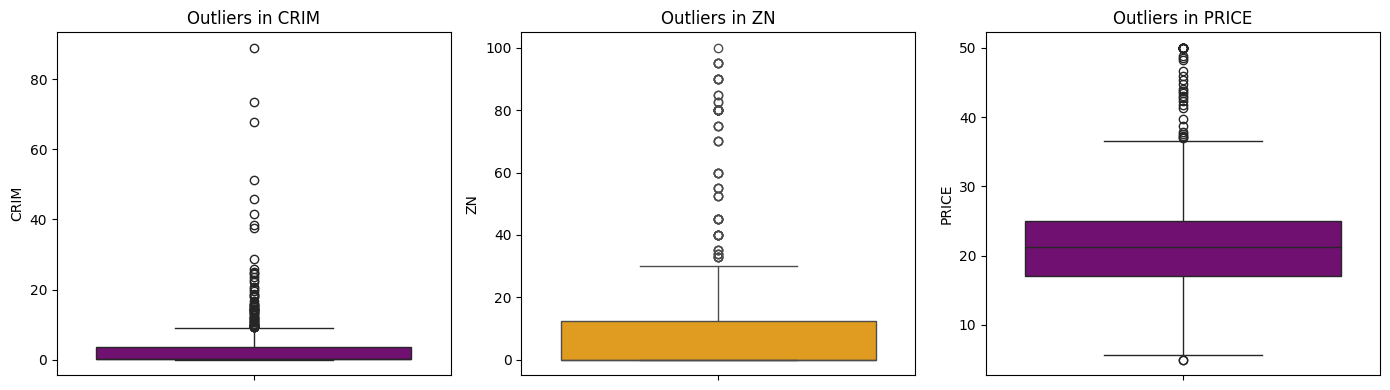

In [15]:
plt.figure(figsize=(14, 4))

# highly skewed structural columns
skewed_cols = ['CRIM', 'ZN', 'PRICE']
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=data[col], color='orange' if col=='ZN' else 'purple')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if 'MEDV' in data.columns and 'PRICE' not in data.columns:
    data = data.rename(columns={'MEDV': 'PRICE'})

# DOCUMENTING MISSING VALUES

null_counts = data.isnull().sum()
print(" True Null Values Count ")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "0 true missing values found.")

# zero-value placeholders
zero_counts = (data == 0).sum()
print("\nZero Value Counts")
print(zero_counts[zero_counts > 0])


# Features that are heavily right-skewed where outliers distort linear models
skewed_features = ['CRIM', 'ZN', 'B']

for col in skewed_features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside the 1.5 * IQR boundary to minimize distortion
    data[col] = np.clip(data[col], lower_bound, upper_bound)

print("\nOutliers successfully capped using the IQR method.")


# 3. SEPARATION & TRAIN-TEST SPLIT
X = data.drop(columns=['PRICE'])
y = data['PRICE']

# Stratify isn't ideal for regression, so we use a stable random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Rooms relative to the age of the house
X_train['ROOM_AGE_RATIO'] = X_train['RM'] / (X_train['AGE'] + 1)
X_test['ROOM_AGE_RATIO'] = X_test['RM'] / (X_test['AGE'] + 1)

# Tax relative to proximity to employment centers (DIS)
X_train['TAX_PER_DIS'] = X_train['TAX'] / (X_train['DIS'] + 1)
X_test['TAX_PER_DIS'] = X_test['TAX'] / (X_test['DIS'] + 1)


# SKEW REDUCTION

# Apply log transform to columns that remain highly non-normal
log_cols = ['CRIM', 'LSTAT']
for col in log_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])



# FEATURE SCALING

scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"training features shape: {X_train_scaled.shape}")
print(f"testing features shape: {X_test_scaled.shape}")


 True Null Values Count 
0 true missing values found.

Zero Value Counts
ZN      372
CHAS    471
dtype: int64

Outliers successfully capped using the IQR method.
training features shape: (404, 15)
testing features shape: (102, 15)


 5-Fold Cross-Validation R² Scores - Training Set
Linear Regression: Mean R² = 0.756 (+/- 0.123)
Decision Tree: Mean R² = 0.636 (+/- 0.168)
Gradient Boosting: Mean R² = 0.832 (+/- 0.120)

 Final Test Set Performance Matrix 
                   MAE (Lower=Better)  MSE (Lower=Better)  \
Linear Regression               2.848              18.287   
Decision Tree                   2.338               9.396   
Gradient Boosting               1.941               6.798   

                   RMSE (Lower=Better)  R² Score (Higher=Better)  
Linear Regression                4.276                     0.751  
Decision Tree                    3.065                     0.872  
Gradient Boosting                2.607                     0.907  


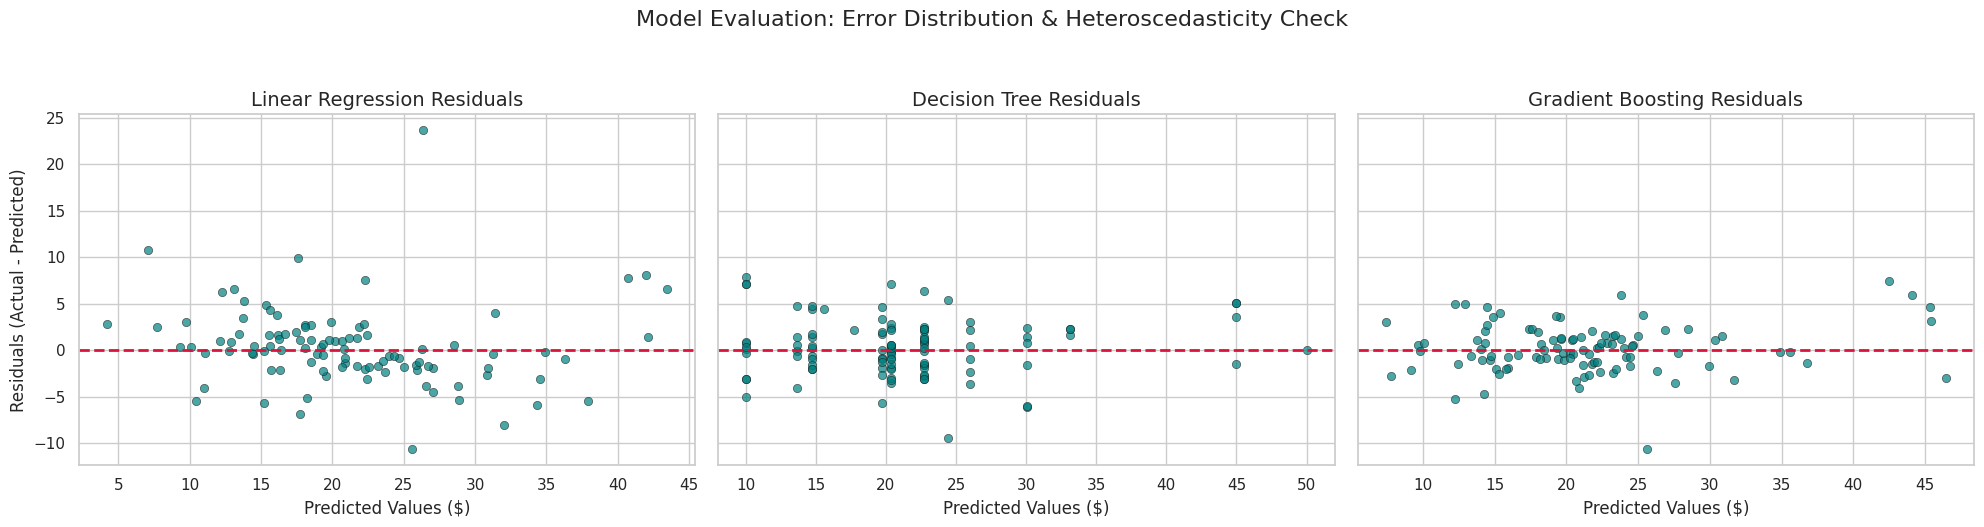

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score

# MODEL SELECTION & TRAINING

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
}

# Train models and evaluate via Cross-Validation to check stability
print(" 5-Fold Cross-Validation R² Scores - Training Set")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"{name}: Mean R² = {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Fit models on the full training subset
for name, model in models.items():
    model.fit(X_train_scaled, y_train)


# COMPREHENSIVE EVALUATION
# Evaluate on the Test Set across multiple metrics
performance_metrics = {}
test_predictions = {}

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    test_predictions[name] = preds  # Save for residual plotting

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    performance_metrics[name] = {
        "MAE (Lower=Better)": round(mae, 3),
        "MSE (Lower=Better)": round(mse, 3),
        "RMSE (Lower=Better)": round(rmse, 3),
        "R² Score (Higher=Better)": round(r2, 3)
    }

# Display results
metrics_df = pd.DataFrame(performance_metrics).T
print("\n Final Test Set Performance Matrix ")
print(metrics_df)


# DIAGNOSTICS: RESIDUAL ANALYSIS PLOTS
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for i, (name, preds) in enumerate(test_predictions.items()):
    residuals = y_test - preds

    # Scatter plot of Predictions vs Residuals
    sns.scatterplot(x=preds, y=residuals, ax=axes[i], color='teal', alpha=0.7, edgecolor='k')
    axes[i].axhline(y=0, color='crimson', linestyle='--', linewidth=2)

    # Titles and formatting
    axes[i].set_title(f"{name} Residuals", fontsize=14)
    axes[i].set_xlabel("Predicted Values ($)", fontsize=12)
    if i == 0:
        axes[i].set_ylabel("Residuals (Actual - Predicted)", fontsize=12)

plt.suptitle("Model Evaluation: Error Distribution & Heteroscedasticity Check", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


 Optimizing Hyperparameters via 5-Fold GridSearchCV
Optimal Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 300}

Tuned Gradient Boosting Test RMSE: 2.595
Tuned Gradient Boosting Test R² Score: 0.908

 Feature Importance Weights
       Feature  Importance Weight
            RM           0.425023
         LSTAT           0.359812
   TAX_PER_DIS           0.056294
           DIS           0.039290
           NOX           0.033835
       PTRATIO           0.024715
           TAX           0.014866
           AGE           0.013135
          CRIM           0.012215
ROOM_AGE_RATIO           0.009588
             B           0.005938
         INDUS           0.002602
           RAD           0.002027
          CHAS           0.000379
            ZN           0.000281


/tmp/ipykernel_910/1601677218.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


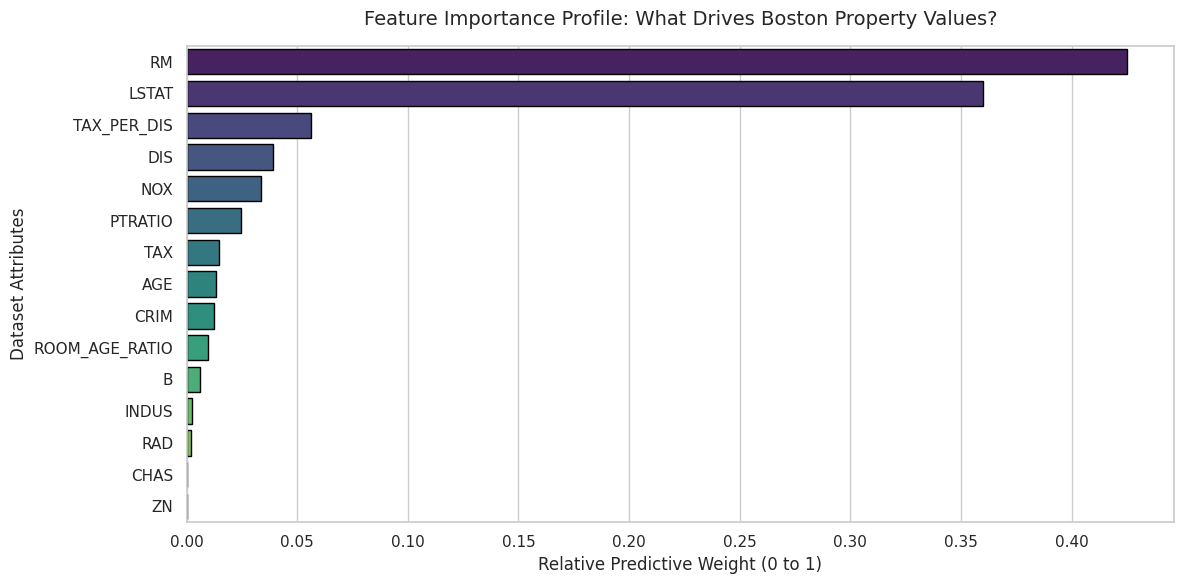

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# PHASE 4: FINE-TUNING

#  Define targeted search grid for the Gradient Boosting Regressor
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 4]
}

print(" Optimizing Hyperparameters via 5-Fold GridSearchCV")
# Initialize the Grid Search with R² scoring across 5 cross-validation folds
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1  # Uses all available CPU cores to speed up execution
)

# Fit on the scaled training features
grid_search.fit(X_train_scaled, y_train)

# Extract the mathematically optimal model
best_gb_model = grid_search.best_estimator_

print(f"Optimal Parameters Found: {grid_search.best_params_}")

# Evaluate the Tuned Model on the Test Set
tuned_preds = best_gb_model.predict(X_test_scaled)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2 = r2_score(y_test, tuned_preds)

print(f"\nTuned Gradient Boosting Test RMSE: {tuned_rmse:.3f}")
print(f"Tuned Gradient Boosting Test R² Score: {tuned_r2:.3f}")


# INFORMED REAL ESTATE DECISION-MAKING

# Extract feature importances calculated by the tuned ensemble
importances = best_gb_model.feature_importances_
feature_names = X_train_scaled.columns

# Construct and sort an Importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Weight': importances
}).sort_values(by='Importance Weight', ascending=False)

print("\n Feature Importance Weights")
print(importance_df.to_string(index=False))

# Plot Publication-Grade Business Insight Visualization
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Importance Weight',
    y='Feature',
    data=importance_df,
    palette='viridis',
    edgecolor='black'
)

plt.title("Feature Importance Profile: What Drives Boston Property Values?", fontsize=14, pad=15)
plt.xlabel("Relative Predictive Weight (0 to 1)", fontsize=12)
plt.ylabel("Dataset Attributes", fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
import pickle

with open('best_boston_housing_model.pkl', 'wb') as model_file:
    pickle.dump(best_gb_model, model_file)

with open('feature_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

